<a href="https://colab.research.google.com/github/PetraAG/TReND-CaMinA/blob/main/notebooks/Kenya26/03-04-AllenTutorial/project_templates/Photon_Drifting%20Mma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
    <h1> Project 6:  Decoding with the Allen Brain Observatory </h1>

In this project, we are going to explore decoding of stimulus informatin using data from the Allen Brain Observatory.  We will look at how we can decode stimulus information and ask questions about what doing so can tell us about neural responses.  This project picks up where the decoding tutorial left off.
    
For the examples we provide we will look at the 'Drifting Gratings' stimulus.  You might consider a similar project that looks at another stimulus.


</div>

In [ ]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

### Standard imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# we're going to need lists of colors below
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.values())

Scikit-learn is the standard machine learning package in python.  You can import it with the command below.

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import confusion_matrix

### Allen Brain Observatory set up

This instantiates the tools in the Allen SDK that allow us to access the Brain Observatory data.

In [ ]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [ ]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"

    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "allen-brain-observatory","visual-coding-2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

The following cells retrieve the same data session that was used in the tutorial.

In [ ]:
# cell_id = 541513979 # Not in use
# exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_id], stimuli=['drifting_gratings'])
# session_id = exps[0]['id']

In [ ]:
def get_experiment_session_list():
    """Returns a list of session_ids for all sessions that use the drifting grating stimulus
    from areas VISp and VISl and from cre lines Cux2 and Slc17"""
    return [x['id'] for x in boc.get_ophys_experiments(stimuli=['drifting_gratings'],
                                                       targeted_structures=['VISp'],
                                                       cre_lines=['Rorb-IRES2-Cre'] )]

In [ ]:
get_experiment_session_list() #The highest number of neurones in Session_ID one 510214538

[510214538,
 644026238,
 587344053,
 590168385,
 531348161,
 501729039,
 512270518,
 527048992]

In [ ]:
session_id = 510214538

The following cell returns the data for session 'session_id' and puts it into the 'data_set' object.

In [ ]:
data_set = boc.get_ophys_experiment_data(session_id)

In [ ]:
timestamps, dff = data_set.get_dff_traces()
stim_table = data_set.get_stimulus_table('drifting_gratings')

In [ ]:
num_neurons = dff.shape[0]
num_trials = stim_table.shape[0]

In [ ]:
stim_ori = stim_table.orientation.dropna().unique()
stim_tf = stim_table.temporal_frequency.dropna().unique()
stim_ori, stim_tf

(array([270., 225.,  45., 315., 180., 135.,  90.,   0.], dtype=float32),
 array([15.,  8.,  2.,  4.,  1.], dtype=float32))

In [ ]:
stim_ori_grid, stim_tf_grid = np.meshgrid(stim_ori, stim_tf)
stim_tf_ori = np.column_stack((stim_ori_grid.ravel(), stim_tf_grid.ravel()))

In [ ]:
for ori in stim_ori:
  for tf in stim_tf:
    print(stim_table[(stim_table.orientation == ori) & (stim_table.temporal_frequency == tf)])

     temporal_frequency  orientation  blank_sweep   start     end
0                  15.0        270.0          0.0     746     805
165                15.0        270.0          0.0   15645   15705
170                15.0        270.0          0.0   16097   16157
228                15.0        270.0          0.0   51133   51192
236                15.0        270.0          0.0   51855   51915
267                15.0        270.0          0.0   54654   54714
281                15.0        270.0          0.0   55918   55978
299                15.0        270.0          0.0   57543   57603
317                15.0        270.0          0.0   59170   59230
324                15.0        270.0          0.0   59802   59862
363                15.0        270.0          0.0   63324   63383
511                15.0        270.0          0.0  104688  104748
563                15.0        270.0          0.0  109383  109443
564                15.0        270.0          0.0  109473  109533
616       

In [ ]:
#stim_table.groupby(['orientation','temporal_frequency']).count()

stim_table

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [ ]:
num_trials

628

In [ ]:
num_neurons

284

In [ ]:
def get_dff_traces_and_stim_table(cell_specimen_id, stimulus):
    """Retrieves DFF traces and stimulus table for a given neuron and stimulus.

    Args:
        cell_specimen_id (int): The ID of the cell specimen.
        stimulus (str): The name of the stimulus (e.g., 'drifting_gratings').

    Returns:
        tuple: A tuple containing:
            - timestamps (numpy.ndarray): Timestamps for the DFF trace.
            - dff_trace (numpy.ndarray): The DF/F trace for the specified cell.
            - stim_table (pandas.DataFrame): The stimulus table for the specified stimulus.
    """
    #identify the session for a given cell id and stimulus
    exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_specimen_id], stimuli=[stimulus])

    #get the session_id for that session
    session_id = exps[0]['id']

    #access the data for that session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for the cell
    timestamps, dff = data_set.get_dff_traces(cell_specimen_ids=[cell_specimen_id])
    dff_trace = dff[0,:]

    #get the stimulus table for the stimulus
    stim_table = data_set.get_stimulus_table(stimulus)

    #return everything
    return (timestamps, dff_trace, stim_table)

In [ ]:
dff_trace = get_dff_traces_and_stim_table()

TypeError: get_dff_traces_and_stim_table() missing 2 required positional arguments: 'cell_specimen_id' and 'stimulus'

In [ ]:
dff.shape , timestamps.shape

((284, 115479), (115479,))

Text(0, 0.5, 'DFF')

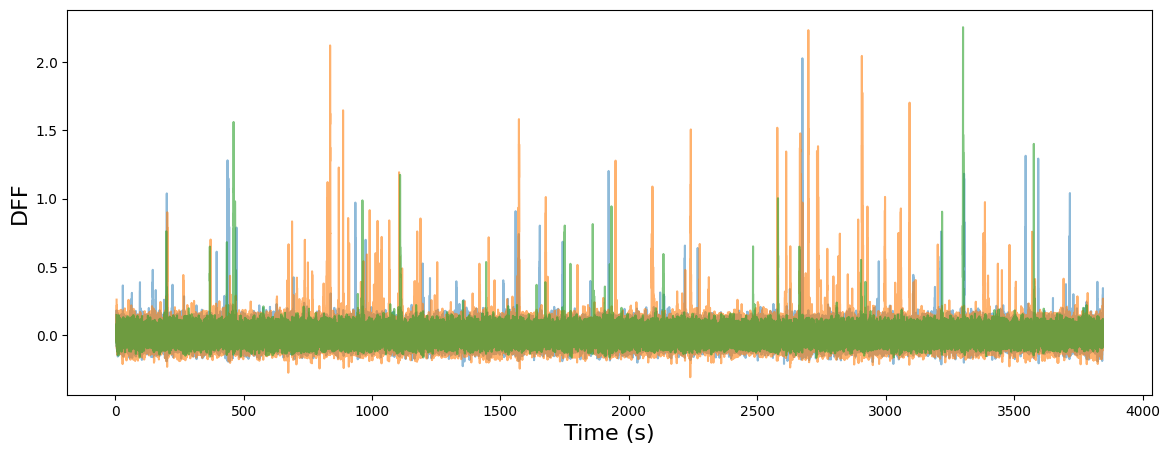

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(timestamps, dff[1,:],alpha = 0.5)
plt.plot(timestamps, dff[200,:],alpha = 0.6)
plt.plot(timestamps, dff[100,:],alpha = 0.6)

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("DFF", fontsize=16)

In [ ]:
stim_table

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [ ]:
def compute_stim_and_response(dff, stim_table):

    num_neurons = dff.shape[0]
    num_trials = stim_table.shape[0]

    activity = np.zeros([num_trials, num_neurons])
    stim = []

    for i, row in stim_table.iterrows():
      activity[i] = dff[:,int(row.start):int(row.end)].mean(axis=1)
      if np.isfinite(row.orientation) and np.isfinite(row.temporal_frequency):
        stim.append(f"{row.orientation}_{row.temporal_frequency}")
      else:
        stim.append('blank') # If either orientation or temporal_frequency is NaN, it's a blank trial

    stim = np.array(stim)

    return activity, stim

In [ ]:
response, stim = compute_stim_and_response(dff, stim_table)
response.shape

(628, 284)

In [ ]:
stim.shape

(628,)

# Classifying cells for stimulus

Let's compute all the tuning curves quickly.

(This is essentially the same computation we did last time don't slightly differently, and for all the neurons simultaneously.)

In [ ]:
def compute_dg_tuning_curve(response, stim, stim_table):
    num_neurons = response.shape[1]

    # Get unique combined stimulus labels from the 'stim' array
    # Filter out 'blank' and sort them for consistent order
    combined_stim_labels_raw = np.unique(stim)
    combined_stim_labels = [label for label in combined_stim_labels_raw if label != 'blank']
    combined_stim_labels.sort()

    num_combined_stim = len(combined_stim_labels)
    tuning_curves = np.zeros([num_neurons, num_combined_stim])

    for i, combined_label in enumerate(combined_stim_labels):
      mask = stim==combined_label
      if np.any(mask): # Only compute mean if there are trials for this stimulus
        tuning_curves[:,i] = response[mask,:].mean(axis=0)
      else:
        # If no trials for this stimulus, fill with NaN to indicate no data
        tuning_curves[:,i] = np.nan

    return tuning_curves, combined_stim_labels # Also return labels for further use

In [ ]:
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)

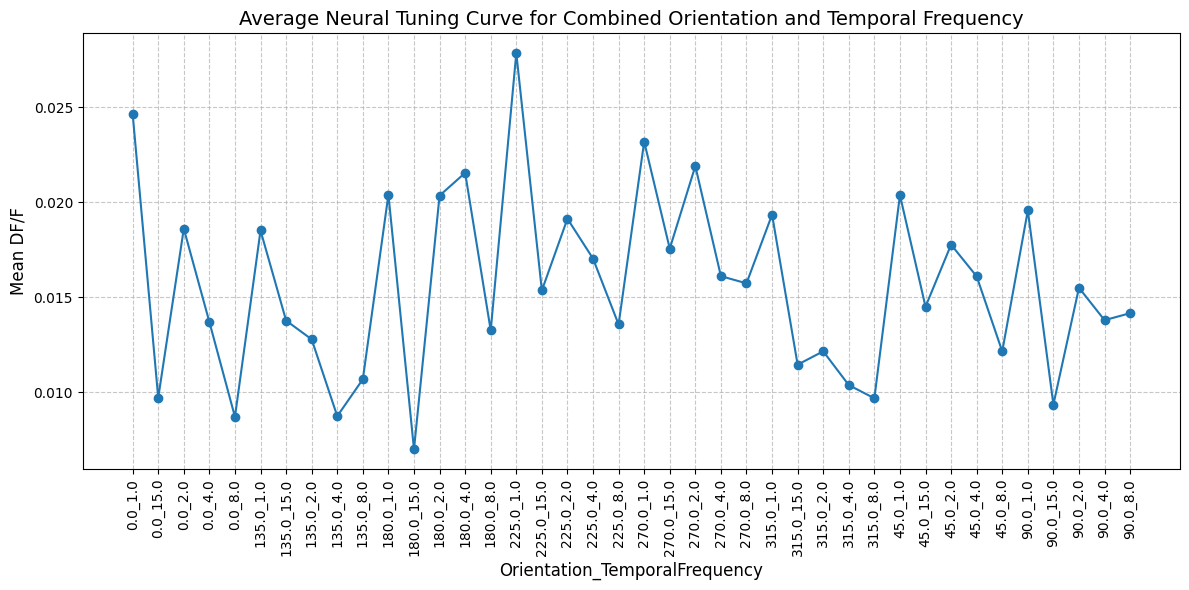

In [ ]:
tuning_curves_data, combined_stim_labels = tuning_curves

# Calculate the mean response across all neurons for each stimulus combination
mean_tuning_curve = np.nanmean(tuning_curves_data, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(combined_stim_labels, mean_tuning_curve, 'o-')

plt.xlabel("Orientation_TemporalFrequency", fontsize=12)
plt.ylabel("Mean DF/F", fontsize=12)
plt.title("Average Neural Tuning Curve for Combined Orientation and Temporal Frequency", fontsize=14)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
orientations = np.sort(stim_table.orientation.unique())
orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']

Let's look at decoding with all of the neurons again.

In [ ]:
test_index = int(0.75*num_trials)

response_test = response[test_index:]
response_train = response[:test_index]

stim_test = stim[test_index:]
stim_train = stim[:test_index]

(response_test.shape, stim_test.shape), (response_train.shape, stim_train.shape)

(((157, 290), (157,)), ((471, 290), (471,)))

In [ ]:
all_neuron_classifier = LDA()
all_neuron_classifier.fit(response_train, stim_train)

LinearDiscriminantAnalysis()

In [ ]:
stim_train_hat = all_neuron_classifier.predict(response_train)
stim_test_hat = all_neuron_classifier.predict(response_test)

In [ ]:
print("Percentage correct on training set:  ", np.mean(stim_train_hat == stim_train))

print("Percentage correct on testing set:  ", np.mean(stim_test_hat == stim_test))

Percentage correct on training set:   1.0
Percentage correct on testing set:   0.6496815286624203


How does this classifier perform on the training set!  What about the test set?  (If there is a difference, why?)

Where is the classifier making mistakes?

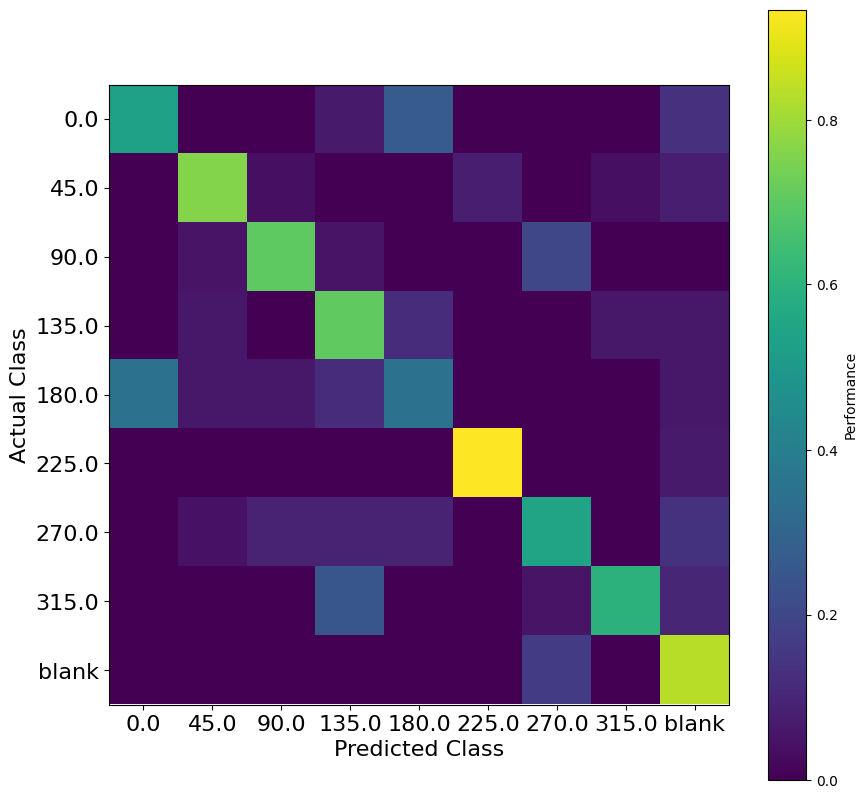

In [ ]:
C = confusion_matrix(stim_test, stim_test_hat, normalize='true', labels=orientation_labels)
# Note that normalization is needed when all classes are not of the same size
# The default is to plot based on counts

num_classes = len(orientation_labels)

plt.figure(figsize=(10, 10))
ax = plt.subplot(111)
cax = ax.imshow(C,interpolation='none', vmin=0, vmax=C.max())

ax.set_xlabel('Predicted Class', fontsize=16)
ax.set_ylabel('Actual Class', fontsize=16)

ax.set_xticks(range(num_classes))
ax.set_xticklabels(orientation_labels, fontsize=16)

ax.set_yticks(range(num_classes))
ax.set_yticklabels(orientation_labels, fontsize=16)

cbar = plt.colorbar(cax)
cbar.set_label('Performance')

We see adding neurons provides more information to the classifier.  How many neurons do we need for good accuracy?

Let's examine how the decoding performance depends upon the number of neurons by randomly selecting a group of neurons of each size.  What does this tell us?  How can we improve this measurement?

In [ ]:
performance = np.zeros(num_neurons-2)

test_index = int(0.75*num_trials)
stim_test_n = stim[test_index:]
stim_train_n = stim[:test_index]

for n in range(2, num_neurons):
  neuron_indices = np.random.permutation(np.arange(num_neurons))[:n] # choose n random neurons

  response_test_n = response[test_index:, neuron_indices]
  response_train_n = response[:test_index, neuron_indices]

  n_classifier = LDA()
  n_classifier.fit(response_train_n, stim_train_n)

  stim_test_hat_n = n_classifier.predict(response_test_n)

  performance[n-2] = np.mean(stim_test_hat_n == stim_test_n)

Text(0.5, 0, 'number of neurons')

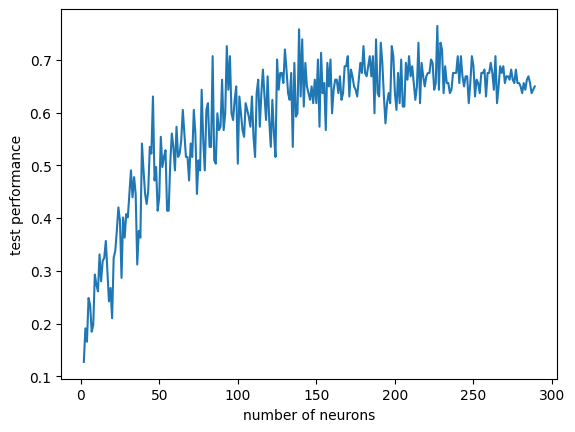

In [ ]:
plt.plot(np.arange(2,num_neurons), performance)
plt.ylabel('test performance')
plt.xlabel('number of neurons')

Questions for future directions:

1. How did we define the test and train sets for these classifications?  What effects do you think this might have on our result?  Can you think of a better way?  What results do you get?

2. Which neurons are the most informative, i.e. which neurons carry the most weight for the classification?  What are the tuning properties of these neurons (i.e. how does the tuning curve relate to the weights in the classifier)?  If you used a different classifier, how would that change your answer to this question?

3.  How would you select the "best" neurons for decoding?  In machine learning this problem is called feature selection.  What methods might be best for this problem?  What are the results?  Are the neurons that are best for decoding the same as the neurons that have robust tuning curves?

4.  If you grab another experiment (code below), what do you need to keep in mind if you want to compare decoding performance across the two experiments?  what can you conclude (if anything) by comparing these two experiments?

Important functions that we used and defined above:

```
# this returns the data for a session identified by session_id
data_set = boc.get_ophys_experiment_data(session_id)

# this returns the timestamps and delta-F/F traces for the set of neurons imaged in that session
timestamps, dff = data_set.get_dff_traces()

# this returns the stimulus information
stim_table = data_set.get_stimulus_table('drifting_gratings')

# compute_stim_and_response is defined IN THIS NOTEBOOK.
response, stim = compute_stim_and_response(dff, stim_table)
# response is [num_trials, num_neurons] and stim is [num_trials]
# response[t,i] gives the response of neuron i to trial t
# stim[t] tells you the stimulus condition of the drifting grating for trial t

# compute_dg_tuning_curve is defined IN THIS NOTEBOOK
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)
# tuning_curves is [num_neurons, num_orientations-1]

```


In [ ]:
session_id=510214538
data_set = boc.get_ophys_experiment_data(session_id)


In [ ]:
data_set.get_stimulus_table('drifting_gratings')

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [ ]:
timestamps, dff = data_set.get_dff_traces()
stim_table = data_set.get_stimulus_table('drifting_gratings')

In [ ]:
stim_table

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [ ]:
num_neurons = dff.shape[0]
num_trials = stim_table.shape[0]

In [ ]:
def compute_stim_and_response(dff, stim_table):

    num_neurons = dff.shape[0]
    num_trials = stim_table.shape[0]

    activity = np.zeros([num_trials, num_neurons])
    stim = []   # why are we using a list?

    for i, row in stim_table.iterrows():
      activity[i] = dff[:,int(row.start):int(row.end)].mean(axis=1) #  compute the mean for *each* neuron
      if np.isfinite(row.orientation):
        stim.append(str(row.orientation))
      else:
        stim.append('blank')

    stim = np.array(stim)

    return activity, stim

In [ ]:
response, stim = compute_stim_and_response(dff, stim_table)

In [ ]:
dff.shape

(284, 115479)

In [ ]:
def get_dff_traces_and_stim_table(cell_specimen_id, stimulus):
    """Retrieves DFF traces and stimulus table for a given neuron and stimulus.

    Args:
        cell_specimen_id (int): The ID of the cell specimen.
        stimulus (str): The name of the stimulus (e.g., 'drifting_gratings').

    Returns:
        tuple: A tuple containing:
            - timestamps (numpy.ndarray): Timestamps for the DFF trace.
            - dff_trace (numpy.ndarray): The DF/F trace for the specified cell.
            - stim_table (pandas.DataFrame): The stimulus table for the specified stimulus.
    """
    #identify the session for a given cell id and stimulus
    exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_specimen_id], stimuli=[stimulus])

    #get the session_id for that session
    session_id = exps[0]['id']

    #access the data for that session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for the cell
    timestamps, dff = data_set.get_dff_traces(cell_specimen_ids=[cell_specimen_id])
    dff_trace = dff[0,:]

    #get the stimulus table for the stimulus
    stim_table = data_set.get_stimulus_table(stimulus)

    #return everything
    return (timestamps, dff_trace, stim_table)

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(timestamps, dff_trace)

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("DFF", fontsize=16)

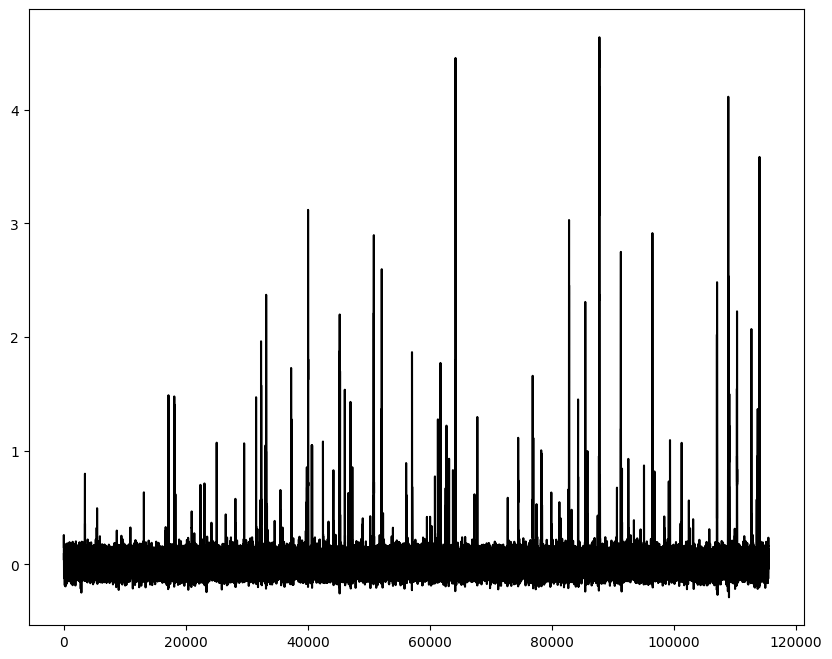

In [ ]:
fig = plt.figure(figsize=(10,8))
plt.plot(dff[10,:], color='black')

In [ ]:
timestamps, dff_trace, stim_table = get_dff_traces_and_stim_table(cell_id, 'drifting_gratings')

IndexError: list index out of range

In [ ]:
dff_trace.shape

NameError: name 'dff_trace' is not defined

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(timestamps, dff_trace)

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("DFF", fontsize=16)

In [ ]:
def compute_dg_tuning_curve(response, stim, stim_table):
    num_neurons = response.shape[1]
    orientations = np.sort(stim_table.orientation.unique())
    orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']
    num_orientations = len(orientations)
    tuning_curves = np.zeros([num_neurons, num_orientations-1])

    for i, ori in enumerate(orientations[:-1]):  # leave out nans
      mask = stim==str(ori)
      tuning_curves[:,i] = response[mask,:].mean(axis=0)

    return tuning_curves

In [ ]:
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)


In [ ]:
orientations = np.sort(stim_table.orientation.unique())
orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']